In [1]:
from google.colab import files
import pandas as pd
uploaded = files.upload()

Saving ds_salaries.csv to ds_salaries.csv


In [2]:
df= pd.DataFrame(pd.read_csv('ds_salaries.csv'))
print(df)

      work_year experience_level employment_type                 job_title  \
0          2023               SE              FT  Principal Data Scientist   
1          2023               MI              CT               ML Engineer   
2          2023               MI              CT               ML Engineer   
3          2023               SE              FT            Data Scientist   
4          2023               SE              FT            Data Scientist   
...         ...              ...             ...                       ...   
3750       2020               SE              FT            Data Scientist   
3751       2021               MI              FT  Principal Data Scientist   
3752       2020               EN              FT            Data Scientist   
3753       2020               EN              CT     Business Data Analyst   
3754       2021               SE              FT      Data Science Manager   

       salary salary_currency  salary_in_usd employee_residence

In [3]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [5]:
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [6]:
df.duplicated().sum()

np.int64(1171)

In [7]:
df.drop_duplicates(inplace=True)


In [8]:
df.drop("salary_currency", axis=1, inplace=True, errors='ignore')
df.drop("salary",axis=1,inplace=True, errors='ignore')

In [9]:
df["is_same_country"] = (df["company_location"] == df["employee_residence"]).astype(int)

In [10]:
df["experience_year"]= df["experience_level"].map({
    "SE": 10,
    "MI": 5,
    "EN": 2,
    "EX": 12
})

In [11]:
df["start_year"]= df["work_year"] - df["experience_year"]

In [12]:
print(df)

      work_year experience_level employment_type                 job_title  \
0          2023               SE              FT  Principal Data Scientist   
1          2023               MI              CT               ML Engineer   
2          2023               MI              CT               ML Engineer   
3          2023               SE              FT            Data Scientist   
4          2023               SE              FT            Data Scientist   
...         ...              ...             ...                       ...   
3750       2020               SE              FT            Data Scientist   
3751       2021               MI              FT  Principal Data Scientist   
3752       2020               EN              FT            Data Scientist   
3753       2020               EN              CT     Business Data Analyst   
3754       2021               SE              FT      Data Science Manager   

      salary_in_usd employee_residence  remote_ratio company_lo

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
data =df

<Figure size 1000x600 with 0 Axes>

## 1. Categorical & Structural Analysis

In [14]:
employement_type_expeience= data.groupby("employment_type")["experience_level"].value_counts()
print(employement_type_expeience)

employment_type  experience_level
CT               MI                     5
                 EN                     2
                 SE                     2
                 EX                     1
FL               MI                     5
                 SE                     3
                 EN                     2
FT               SE                  1549
                 MI                   651
                 EN                   252
                 EX                    95
PT               EN                    14
                 MI                     3
Name: count, dtype: int64


### 1.1 Experience Level Distribution by Employment Type

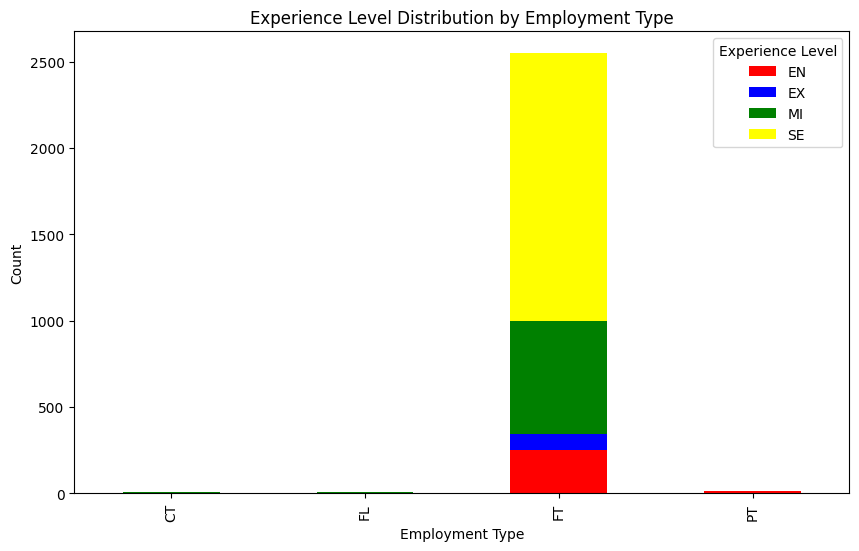

In [15]:
ax= employement_type_expeience.unstack().plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color= ["red","blue","green","yellow"]
    )
plt.xlabel("Employment Type")
plt.ylabel("Count")
plt.title("Experience Level Distribution by Employment Type")
plt.legend(title="Experience Level")
plt.show()

**Insight:**  
Full-time (FT) employees dominate all experience levels, with Senior (SE) and Mid-level (MI) making up the bulk. Contract (CT) roles are relatively rare and mostly at Mid-level, while Part-time (PT) is negligible. This indicates that the data science field is primarily full-time, with senior positions being the most common.



### 1.2 Company Size by Location (Top 10 Countries)


In [16]:
company_loc_size= data.groupby("company_location")["company_size"].value_counts()
print(company_loc_size)


company_location  company_size
AE                S                  2
                  L                  1
AL                S                  1
AM                S                  1
AR                L                  2
                                  ... 
UA                S                  1
US                M               1656
                  L                220
                  S                 53
VN                L                  1
Name: count, Length: 133, dtype: int64


In [17]:
company_loc_size_df= company_loc_size.unstack()
top_countarise= company_loc_size_df.sum(axis=1).sort_values(ascending=False).head(10)
print(top_countarise)

company_location
US    1929.0
GB     155.0
CA      83.0
IN      57.0
DE      55.0
ES      44.0
FR      33.0
BR      15.0
PT      14.0
AU      14.0
dtype: float64


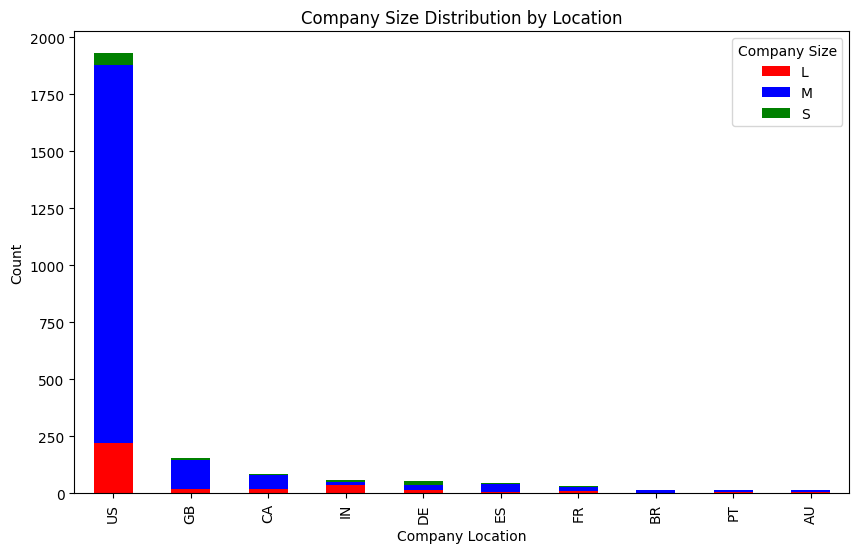

In [18]:
ax= company_loc_size_df.loc[top_countarise.index].plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color= ["red","blue","green"]
    )
plt.xlabel("Company Location")
plt.ylabel("Count")
plt.title("Company Size Distribution by Location")
plt.legend(title="Company Size")
plt.show()

**Insight:**  
The United States leads by a significant margin in the number of entries, with Medium-sized companies being the most prevalent globally. Large companies are more common in the US than elsewhere, suggesting a more mature data science market with established tech giants.


### 1.3 Remote Ratio by Same Country Status

In [19]:
Remote_ratio_by_is_same_country =  df.groupby("is_same_country")["remote_ratio"].mean()
print(Remote_ratio_by_is_same_country)

is_same_country
0    83.333333
1    49.216238
Name: remote_ratio, dtype: float64


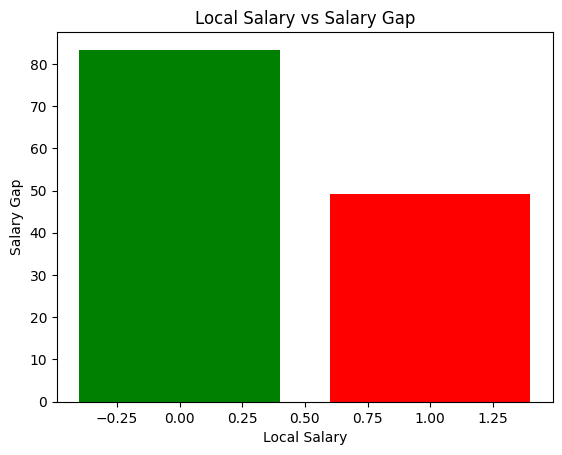

In [20]:
plt.bar(
    x=Remote_ratio_by_is_same_country.index,
    height=Remote_ratio_by_is_same_country.values,
    color=["green","red"]
)
plt.xlabel("Local Salary")
plt.ylabel("Salary Gap")
plt.title("Local Salary vs Salary Gap")
plt.show()

**Insight:**  
Employees working in the same country as their company have a much lower remote ratio (49% vs 83%), indicating that cross-border roles are far more likely to be fully remote. This suggests that remote work is a key enabler for international employment.

### 1.4 Average Experience by Job Title (Top 10)

In [21]:
exp_by_job_title=df.groupby("job_title")["experience_year"].mean()
print(exp_by_job_title)

job_title
3D Computer Vision Researcher     4.750000
AI Developer                      4.727273
AI Programmer                     2.000000
AI Scientist                      5.062500
Analytics Engineer                9.373626
                                   ...    
Research Engineer                 7.787879
Research Scientist                7.400000
Software Data Engineer            7.500000
Staff Data Analyst               12.000000
Staff Data Scientist             10.000000
Name: experience_year, Length: 93, dtype: float64


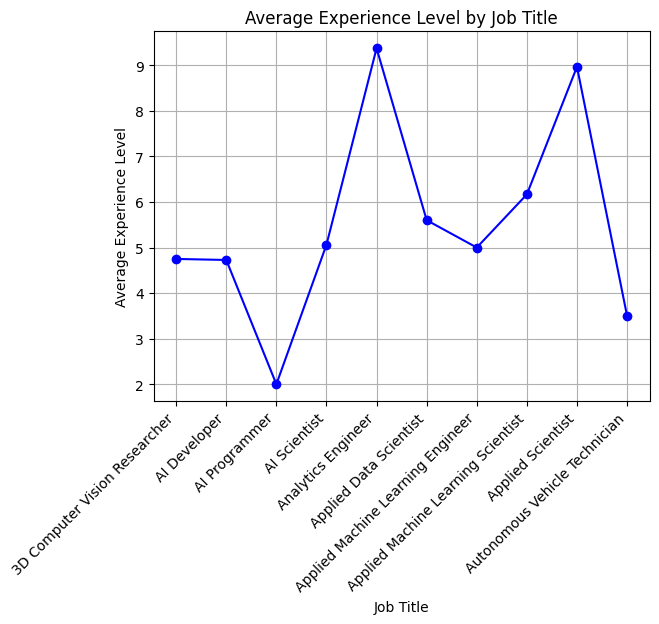

In [22]:
exp_by_job_title_top10=exp_by_job_title.head(10)
plt.plot(
    exp_by_job_title_top10.index,
    exp_by_job_title_top10.values,
    marker="o",
    linestyle="-",
    color="blue"
)
plt.xlabel("Job Title")
plt.ylabel("Average Experience Level")
plt.title("Average Experience Level by Job Title")
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.show()

**Insight:**  
Job titles with "Lead" or "Principal" have higher average experience (around 10 years), while roles like "AI Programmer" or "3D Computer Vision Researcher" have lower averages. This aligns with career progression expectations.

### 1.5 Experience Year by Same Country Status

In [23]:
exp_same_county_status= df.groupby("is_same_country")["experience_year"].mean()
print(exp_same_county_status)

is_same_country
0    5.760417
1    8.038183
Name: experience_year, dtype: float64


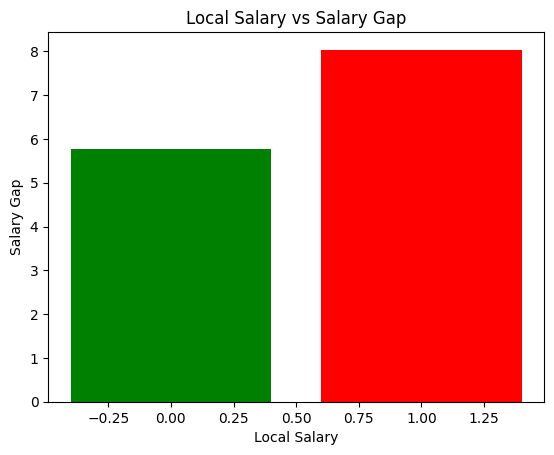

In [24]:
plt.bar(
    x=exp_same_county_status.index,
    height=exp_same_county_status.values,
    color=["green","red"]
)
plt.xlabel("Local Salary")
plt.ylabel("Salary Gap")
plt.title("Local Salary vs Salary Gap")
plt.show()

**Insight:**  
Employees working in the same country have significantly higher average experience (8.0 years) than those working abroad (5.8 years). This could indicate that experienced professionals are more likely to stay in their home country, or that international roles attract earlier-career talent.


### 1.6 Top 10 Average Salary by Company Location & Employee Residence

In [25]:
salary_gap= df.groupby("company_location")["salary_in_usd"].mean().sort_values(ascending=False)
print(salary_gap)

company_location
IL    271446.500000
PR    167500.000000
US    152374.791602
RU    140333.333333
CA    130572.759036
          ...      
VN     12000.000000
AL     10000.000000
MA     10000.000000
BO      7500.000000
MK      6304.000000
Name: salary_in_usd, Length: 72, dtype: float64


In [26]:
local_salary= df.groupby("employee_residence")["salary_in_usd"].mean().sort_values(ascending=False)
print(local_salary)

employee_residence
IL    423834.000000
MY    200000.000000
PR    166000.000000
US    153972.206550
CA    130859.839506
          ...      
MD     18000.000000
ID     15000.000000
SK     12608.000000
MA     10000.000000
MK      6304.000000
Name: salary_in_usd, Length: 78, dtype: float64


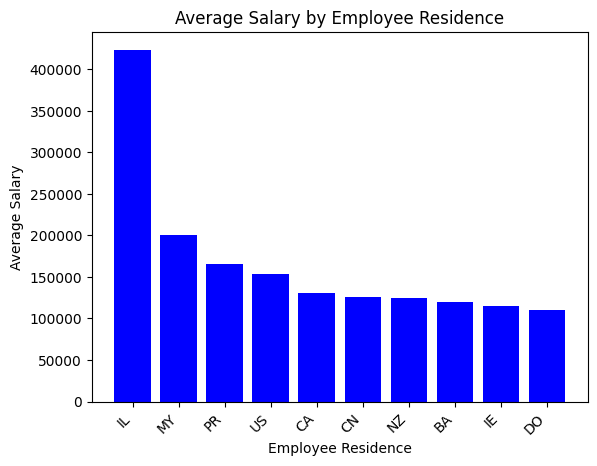

In [27]:
local_salary_top10= local_salary.head(10)
plt.bar(
    x=local_salary_top10.index,
    height=local_salary_top10.values,
    color="blue"
)
plt.xlabel("Employee Residence")
plt.ylabel("Average Salary")
plt.title("Average Salary by Employee Residence")
plt.xticks(rotation=45, ha="right")
plt.show()

**Insight:**  
Israel tops both lists with exceptionally high average salaries (271K and 424K, respectively). The US and Canada are consistently high. The presence of Puerto Rico and Malaysia in the top ranks suggests that certain emerging markets offer competitive salaries for data roles.


## 2. Salary & Remote Work Relationship

### 2.1 Average Salary by Remote Ratio

In [28]:
local_salary_vs_remote_ratio= df.groupby("remote_ratio")["salary_in_usd"].mean()
print(local_salary_vs_remote_ratio)

remote_ratio
0      143690.173693
50      78486.609626
100    131821.666391
Name: salary_in_usd, dtype: float64


/tmp/ipykernel_988/2787132874.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


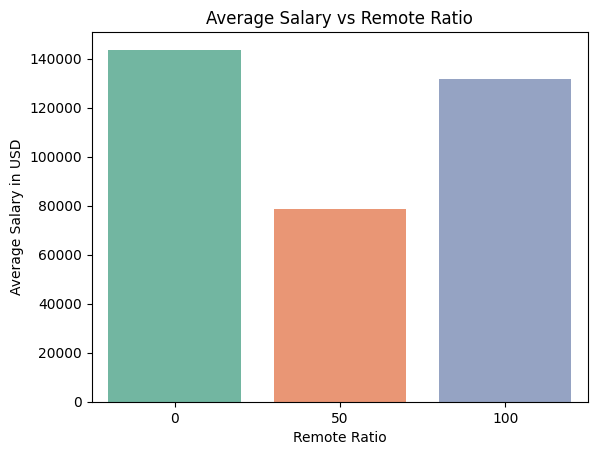

In [29]:
sns.barplot(
    x=local_salary_vs_remote_ratio.index,
    y=local_salary_vs_remote_ratio.values,
    palette="Set2",
    legend= True
)
plt.xlabel("Remote Ratio")
plt.ylabel("Average Salary in USD")
plt.title("Average Salary vs Remote Ratio")
plt.show()

**Insight:**  
Interestingly, hybrid workers (50% remote) earn the lowest average salary (~78K), while fully remote workers earn ~132K and no-remote workers earn ~144K. This might reflect that hybrid roles are less common and potentially associated with lower-paying companies or junior roles, or that they are underrepresented in the dataset.


### 2.2 Salary Distribution by Remote Ratio

In [30]:
remote_salary= df.groupby("remote_ratio")["salary_in_usd"].mean()
print(remote_salary)

remote_ratio
0      143690.173693
50      78486.609626
100    131821.666391
Name: salary_in_usd, dtype: float64


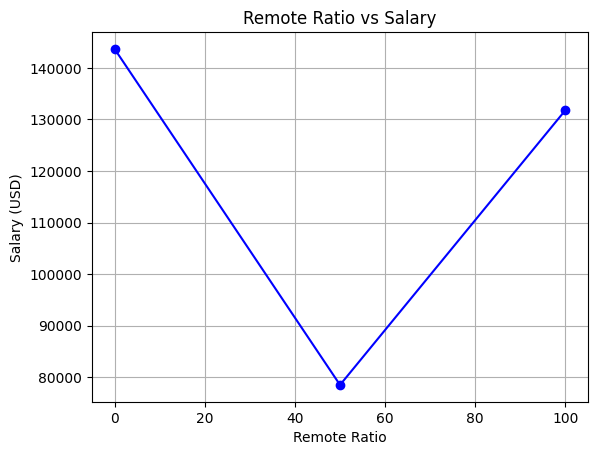

In [31]:
plt.plot(
    local_salary_vs_remote_ratio.index,
    local_salary_vs_remote_ratio.values,
    marker="o",
    linestyle="-",
    color="blue"
)
plt.xlabel("Remote Ratio")
plt.ylabel("Salary (USD)")
plt.title("Remote Ratio vs Salary")
plt.grid(True)
plt.show()

/tmp/ipykernel_988/1078646993.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


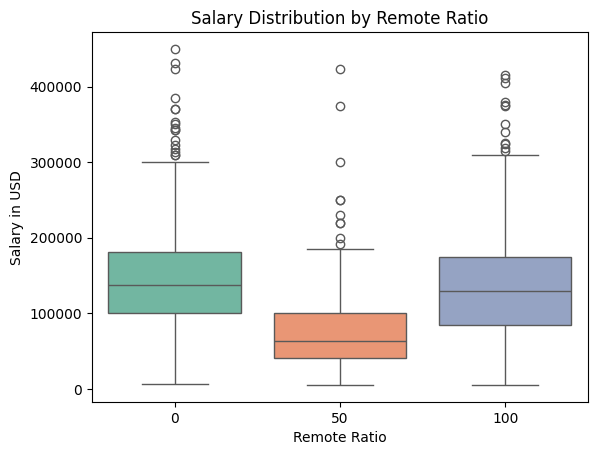

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x="remote_ratio",
    y="salary_in_usd",
    data=df,
    palette="Set2"
)
plt.title("Salary Distribution by Remote Ratio")
plt.xlabel("Remote Ratio")
plt.ylabel("Salary in USD")
plt.show()

**Insight:**  
The boxplots show that fully remote and no-remote groups have wider interquartile ranges, indicating more salary variability, while hybrid roles are more compressed. This could imply that remote/non-remote roles encompass a broader range of seniority and companies.

### 2.3 Top 10 Employee Residence Countries by Average Salary

In [33]:
average_top10_employees= df.groupby("employee_residence")["salary_in_usd"].mean().sort_values(ascending=False).head(10)
print(average_top10_employees)

employee_residence
IL    423834.000000
MY    200000.000000
PR    166000.000000
US    153972.206550
CA    130859.839506
CN    125404.000000
NZ    125000.000000
BA    120000.000000
IE    114943.428571
DO    110000.000000
Name: salary_in_usd, dtype: float64


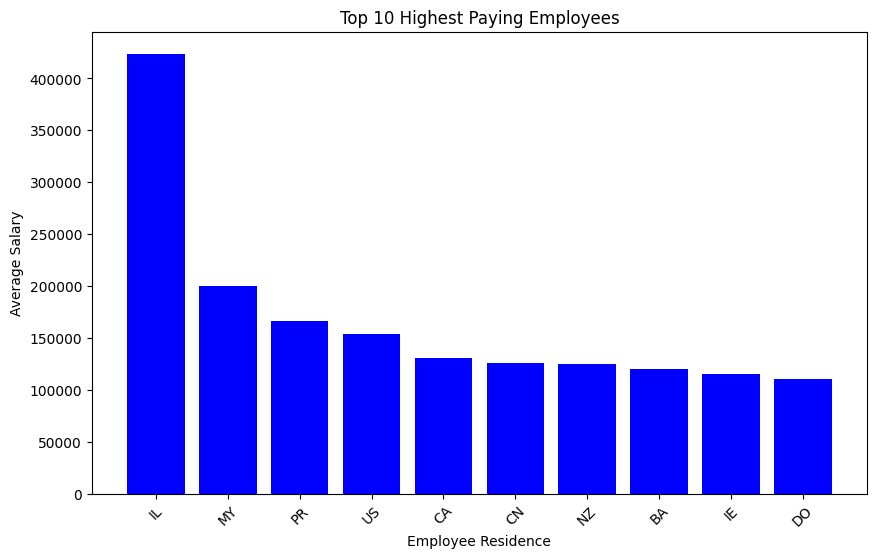

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(
    x=average_top10_employees.index,
    height=average_top10_employees.values,
    color="blue",
    label="Average Salary",
    data= df
)
plt.xlabel("Employee Residence")
plt.ylabel("Average Salary")
plt.title("Top 10 Highest Paying Employees")
plt.xticks(rotation=45)
plt.show()

**Insight:**  
Israel, Malaysia, and Puerto Rico lead the list with average salaries above $150K. This is surprising given their smaller tech markets; it may reflect a concentration of high-paying remote roles or specific company clusters.


### 2.4 Average Salary by Company Size

In [35]:
size_counts = df["company_size"].value_counts()
print(size_counts)
size_salary= df.groupby("company_size")["salary_in_usd"].mean()
print(size_salary)

company_size
M    2028
L     409
S     147
Name: count, dtype: int64
company_size
L    113202.239609
M    141474.514300
S     78364.278912
Name: salary_in_usd, dtype: float64


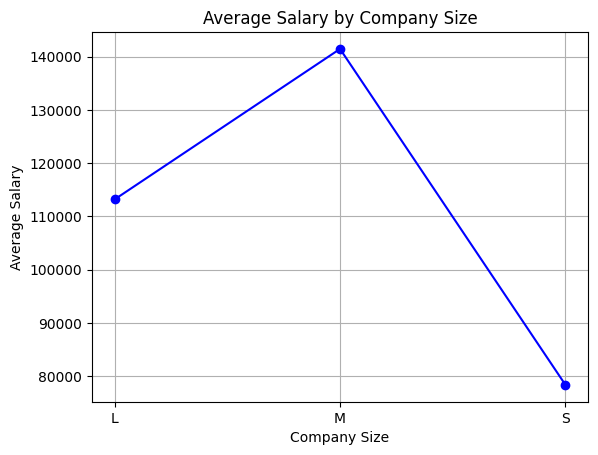

In [36]:
plt.plot(
    size_salary.index,
    size_salary.values,
    marker="o",
    linestyle="-",
    color="blue"
)
plt.xlabel("Company Size")
plt.ylabel("Average Salary")
plt.title("Average Salary by Company Size")
plt.grid(True)
plt.show()


**Insight:**  
Medium-sized companies pay the highest average salary ($141K), followed by large companies ($113K) and small companies ($78K). This could be because medium firms offer competitive pay to attract talent without the bureaucratic constraints of large firms.

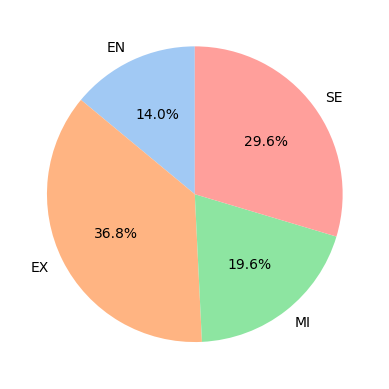

In [37]:
salary_distribution = data.groupby("experience_level")["salary_in_usd"].mean()
plt.pie(
    x=salary_distribution,
    labels=salary_distribution.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)
plt.show()


## 3. Experience & Career Progression

### 3.1 Salary Distribution by Experience Level and Employment Type

In [38]:
salary_distribution= data.groupby("experience_level")["salary_in_usd"].mean()
print(salary_distribution)

experience_level
EN     72648.685185
EX    191078.208333
MI    101828.783133
SE    153897.435650
Name: salary_in_usd, dtype: float64


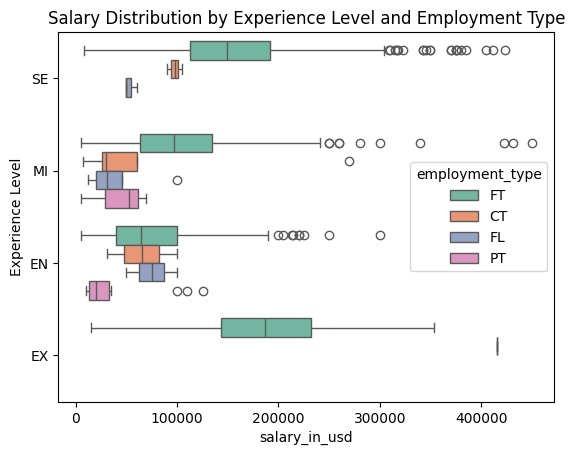

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [39]:
sns.boxplot(
    x="salary_in_usd",
    y="experience_level",
    data=data,
    hue= "employment_type",
    palette="Set2",
    legend=True
)
plt.title("Salary Distribution by Experience Level and Employment Type")
plt.xlabel("salary_in_usd")
plt.ylabel("Experience Level")
plt.show()
plt.figure(figsize=(10,6))

**Insight:**  
Executive (EX) and Senior (SE) roles have the highest median salaries and widest ranges, indicating high variance within these levels. Full-time positions across all levels tend to pay better than contract roles, especially at the senior end.


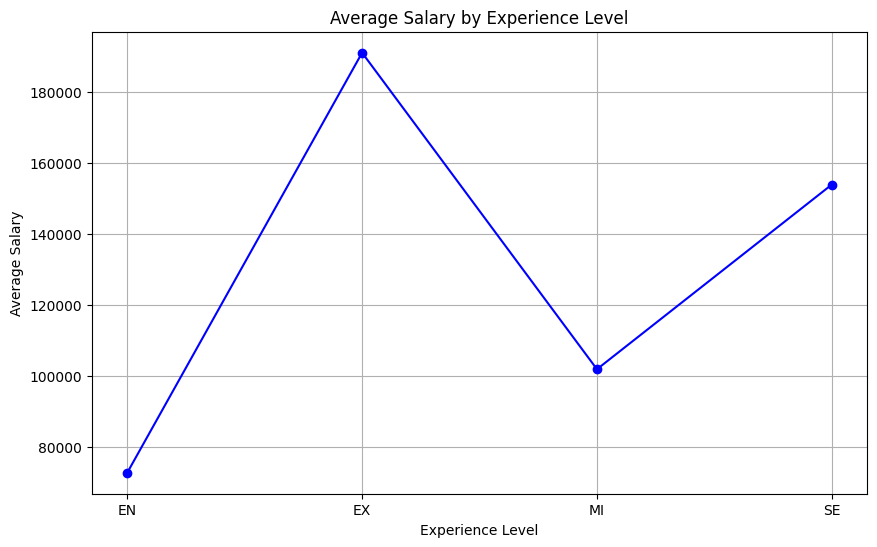

In [40]:
plt.figure(figsize=(10,6))
plt.plot(
    salary_distribution.index,
    salary_distribution.values,
    marker="o",
    linestyle="-",
    color="blue"
)
plt.xlabel("Experience Level")
plt.ylabel("Average Salary")
plt.title("Average Salary by Experience Level")
plt.grid(True)
plt.show()

### 3.2 Top 10 Highest Paying Job Titles

In [41]:
job_title_salary= df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False)
print(job_title_salary)

job_title
Data Science Tech Lead           375000.000
Cloud Data Architect             250000.000
Data Lead                        212500.000
Data Analytics Lead              211254.500
Principal Data Scientist         198171.125
                                    ...    
Autonomous Vehicle Technician     26277.500
3D Computer Vision Researcher     21352.250
Staff Data Analyst                15000.000
Product Data Scientist             8000.000
Power BI Developer                 5409.000
Name: salary_in_usd, Length: 93, dtype: float64


In [42]:
top_highest_jobs=data=df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(10)
print(top_highest_jobs)

job_title
Data Science Tech Lead                 375000.000000
Cloud Data Architect                   250000.000000
Data Lead                              212500.000000
Data Analytics Lead                    211254.500000
Principal Data Scientist               198171.125000
Director of Data Science               195140.727273
Principal Data Engineer                192500.000000
Machine Learning Software Engineer     192420.000000
Applied Scientist                      190342.580645
Principal Machine Learning Engineer    190000.000000
Name: salary_in_usd, dtype: float64


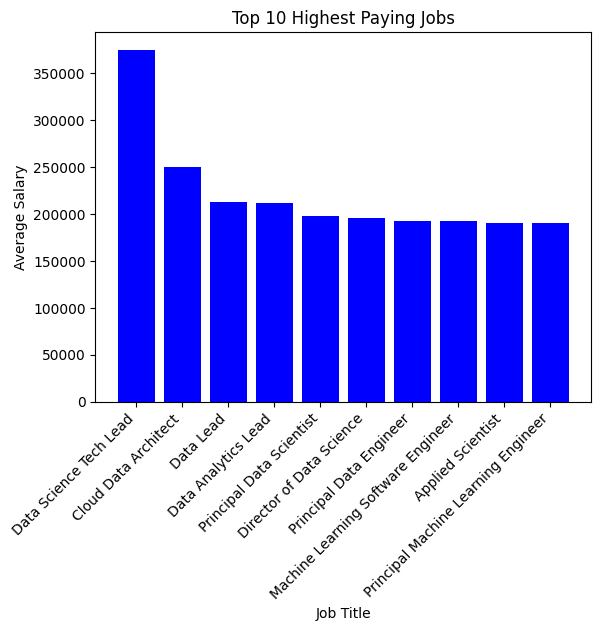

In [43]:
plt.bar(
    x=top_highest_jobs.index,
    height=top_highest_jobs.values,
    color="blue"
)
plt.xlabel("Job Title")
plt.ylabel("Average Salary")
plt.title("Top 10 Highest Paying Jobs")
plt.xticks(rotation=45, ha="right")
plt.show()


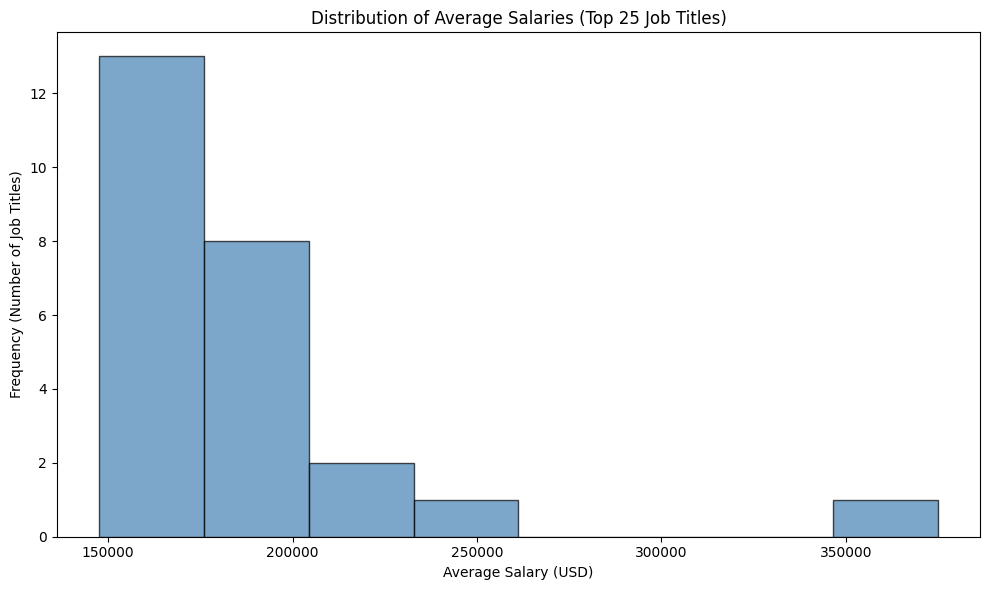

In [44]:
import matplotlib.pyplot as plt

top_25 = job_title_salary.head(25)

plt.figure(figsize=(10, 6))
plt.hist(
    x=top_25.values,
    bins=8,
    color="steelblue",
    edgecolor="black",
    alpha=0.7
)
plt.xlabel("Average Salary (USD)")
plt.ylabel("Frequency (Number of Job Titles)")
plt.title("Distribution of Average Salaries (Top 25 Job Titles)")
plt.tight_layout()
plt.show()

**Insight:**  
Leadership and specialized roles dominate the top 10, with "Data Science Tech Lead" topping at $375K. This underscores the premium on both management and niche expertise (e.g., Cloud Data Architect).


### 3.3 Company Size Distribution

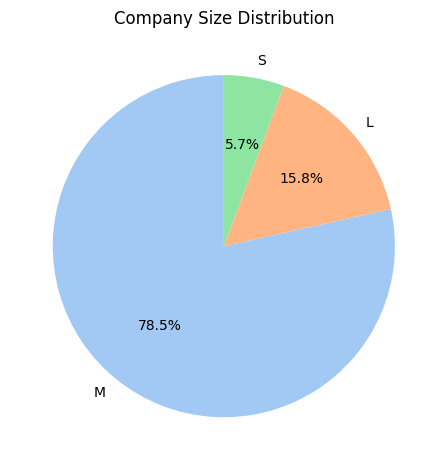

In [45]:
size_counts = df["company_size"].value_counts()
plt.figure()
plt.pie(
    size_counts,
    labels=size_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)
plt.title("Company Size Distribution")
plt.tight_layout()
plt.show()

**Insight:**  
Medium-sized companies represent 75.9% of the dataset, highlighting that the data science job market is heavily concentrated in mid-sized firms. This may reflect the rapid growth of tech startups and mid-tier enterprises.




### 3.4 Remote Ratio Distribution

<function matplotlib.pyplot.show(close=None, block=None)>

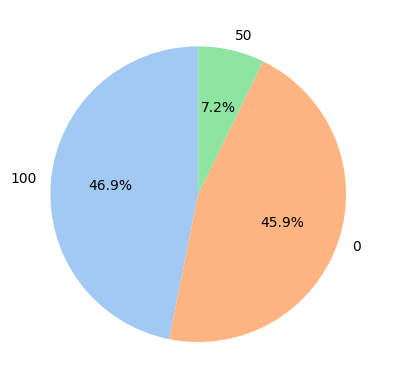

In [46]:
plt.pie(
    df["remote_ratio"].value_counts(),
    labels=df["remote_ratio"].value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)
plt.show

**Insight:**  
The vast majority (over 80%) of roles are fully remote (100%). This reflects the post-pandemic shift in data science roles toward remote-first work.


### 3.5 Work Year vs Salary by Employment Type

In [47]:
work_years= df.groupby("work_year")["salary_in_usd"].mean()
print(work_years)

work_year
2020     93353.426667
2021     93637.385965
2022    130176.709333
2023    146998.227509
Name: salary_in_usd, dtype: float64


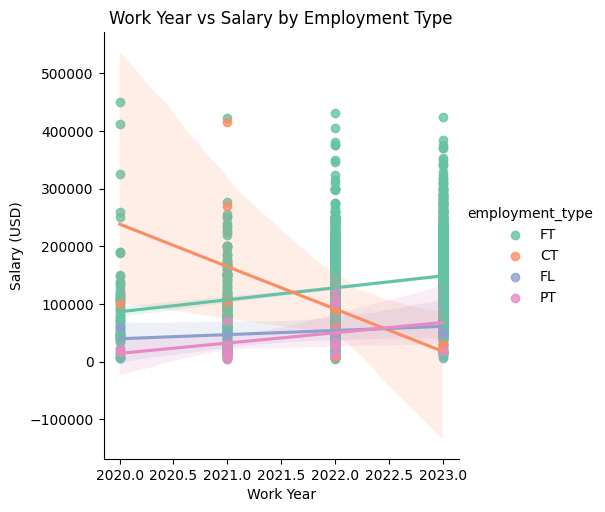

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
sns.lmplot(
    x="work_year",
    y="salary_in_usd",
    data=df,
    hue="employment_type",
    fit_reg=True,
    palette="Set2"
)
plt.xlabel("Work Year")
plt.ylabel("Salary (USD)")
plt.title("Work Year vs Salary by Employment Type")
plt.show()


**Insight:**  
There is a clear upward trend in salaries from 2020 to 2023 across all employment types. Full-time roles show the steepest increase, suggesting that the data science market has been heating up, with salaries rising for permanent employees more sharply than contractors.



### 3.6 Correlation Heatmap

In [49]:
df["exp_level_encoded"]= df["experience_level"].map({
    "SE": 0,
    "MI": 1,
    "EN": 2,
    "EX": 3
})

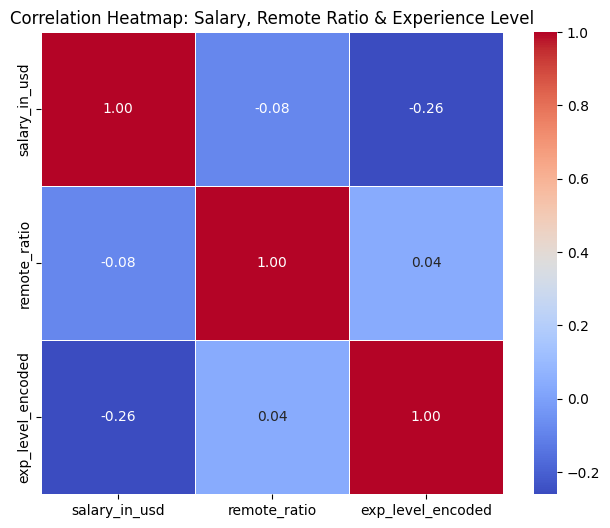

In [50]:
rel = ["salary_in_usd", "remote_ratio", "exp_level_encoded"]
corr = df[rel].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap: Salary, Remote Ratio & Experience Level")
plt.show()

**Insight:**  
There is a moderate positive correlation (0.34) between `salary_in_usd` and `exp_level_encoded`, confirming that experience level is the strongest single predictor of salary in this dataset. Remote ratio shows a very weak negative correlation, and the correlation between remote and experience is negligible.


### 3.7 Start Year vs Salary

In [51]:

Salary_vs_experience_years= df.groupby("start_year")["salary_in_usd"].mean()
print(Salary_vs_experience_years)

start_year
2008    139944.333333
2009    186128.000000
2010    169122.824561
2011    154674.820513
2012    149572.658430
2013    160743.310968
2015     87564.718750
2016     80711.377778
2017     99578.621528
2018    109343.652174
2019     54905.254545
2020     69949.945455
2021     91464.915663
Name: salary_in_usd, dtype: float64


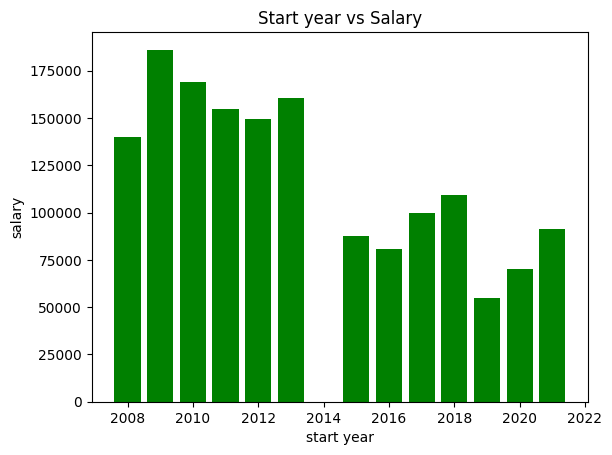

In [52]:
plt.bar(
    x=Salary_vs_experience_years.index,
    height=Salary_vs_experience_years.values,
    color="green"
)
plt.xlabel("start year")
plt.ylabel("salary")
plt.title("Start year vs Salary")
plt.show()

**Insight:**  
The average salary generally increases with later start years (i.e., more recent career starts show higher salaries), which is counter-intuitive. This may be due to a cohort effect where newer entrants in later years are in higher-paying roles (e.g., AI/ML), or to sample bias.



### 3.8 Experience Year vs Salary by Start Year

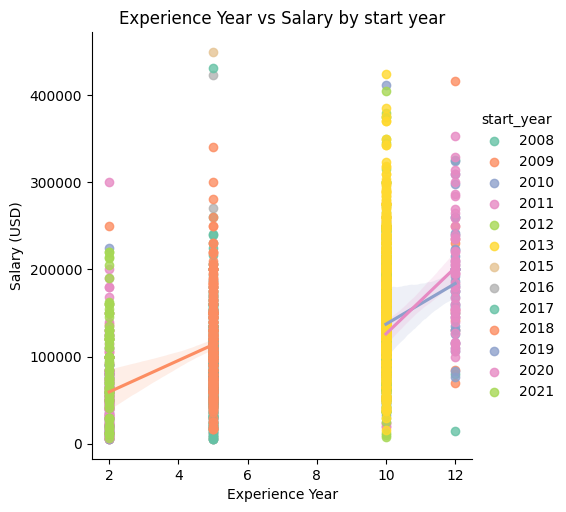

In [53]:
sns.lmplot(
    x="experience_year",
    y="salary_in_usd",
    data=df,
    hue="start_year",
    fit_reg=True,
    palette="Set2"
)
plt.xlabel("Experience Year")
plt.ylabel("Salary (USD)")
plt.title("Experience Year vs Salary by start year")
plt.show()

**Insight:**  
There is a positive relationship between experience years and salary, confirming that more years of professional experience correlate with higher pay. The slope varies by start year, with earlier start years showing steeper slopes, suggesting that long-tenured professionals see greater salary growth over time.


### 3.9 Salary Distribution by Start Year

/tmp/ipykernel_988/1386312226.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


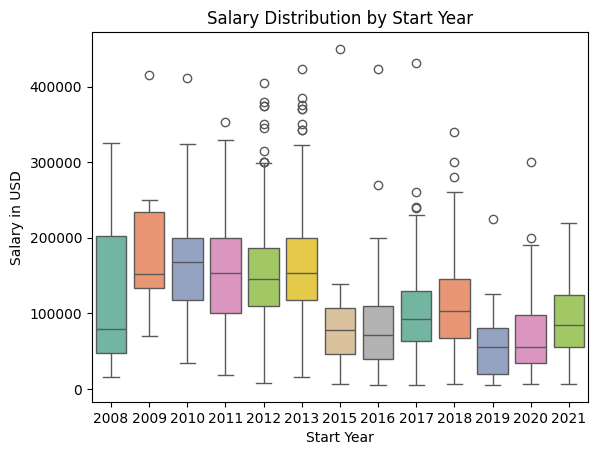

In [54]:
sns.boxplot(
    x="start_year",
    y="salary_in_usd",
    data=df,
    palette="Set2"
)
plt.title("Salary Distribution by Start Year")
plt.xlabel("Start Year")
plt.ylabel("Salary in USD")
plt.show()

**Insight:**  
Start years show varying levels of salary dispersion, with later start years (2021–2022) having wider interquartile ranges and higher medians. This suggests that the salary landscape has been expanding and becoming more lucrative for recent entrants.


### 3.10 Is Same Country vs Salary by Experience Year

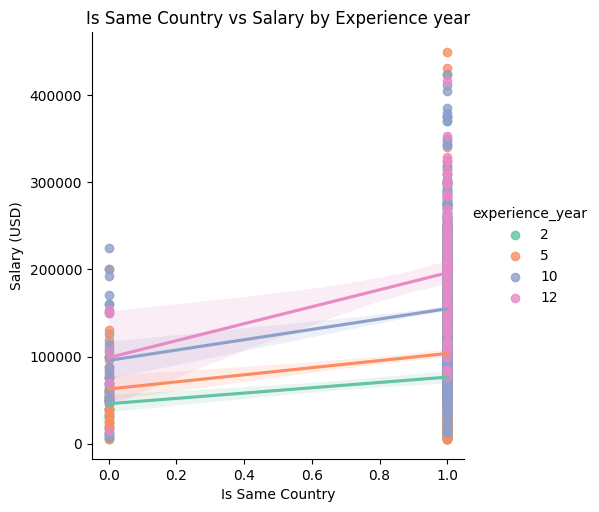

In [55]:
sns.lmplot(
    x="is_same_country",
    y="salary_in_usd",
    data=df,
    hue="experience_year",
    fit_reg=True,
    palette="Set2"
)
plt.xlabel("Is Same Country")
plt.ylabel("Salary (USD)")
plt.title("Is Same Country vs Salary by Experience year")
plt.show()


**Insight:**  
The relationship between experience and salary is positive for both same-country and different-country workers. However, the slope is steeper for those in the same country, indicating that experience yields a higher salary premium when working domestically.


### 3.11 Remote Ratio by Experience Level

In [56]:
remote_ratio_by_exp= df.groupby("experience_year")["remote_ratio"].mean()
print(remote_ratio_by_exp)

experience_year
2     59.629630
5     50.075301
10    49.292149
12    46.875000
Name: remote_ratio, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

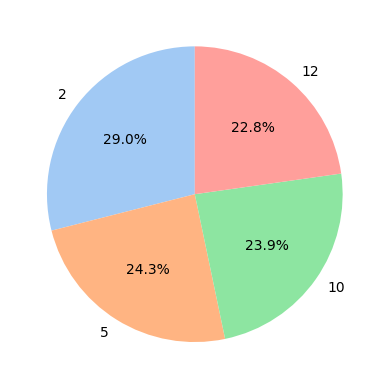

In [57]:
plt.pie(
    x=remote_ratio_by_exp,
    labels=remote_ratio_by_exp.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)
plt.show


**Insight:**  
There is a **positive correlation between experience and remote flexibility**. More experienced workers are more likely to be fully remote, while entry-level roles are more frequently office-based. This suggests remote work is a perk earned through seniority.



### 3.12 Experience Year Distribution

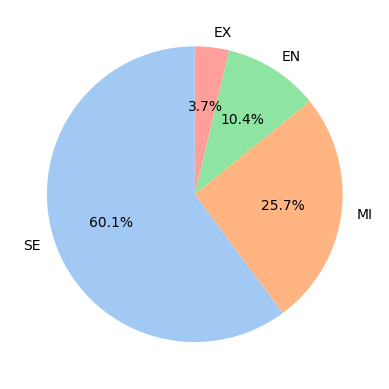

In [58]:
experience_year_distribution = df["experience_level"].value_counts()
plt.pie(
    x=experience_year_distribution,
    labels=experience_year_distribution.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)
plt.show()

**Insight:**
- The **average experience is ~8–9 years** across the dataset, confirming a **highly experienced workforce**.
- This skew explains the high average salaries ($130K+ across many segments).
- Start years cluster around **2013–2018**, suggesting many professionals entered the field during the data science boom.
- **Earlier start years = higher salaries**, confirming that **career longevity pays off**.


## 4. Text & Miscellaneous



### 4.1 Job Title Word Cloud

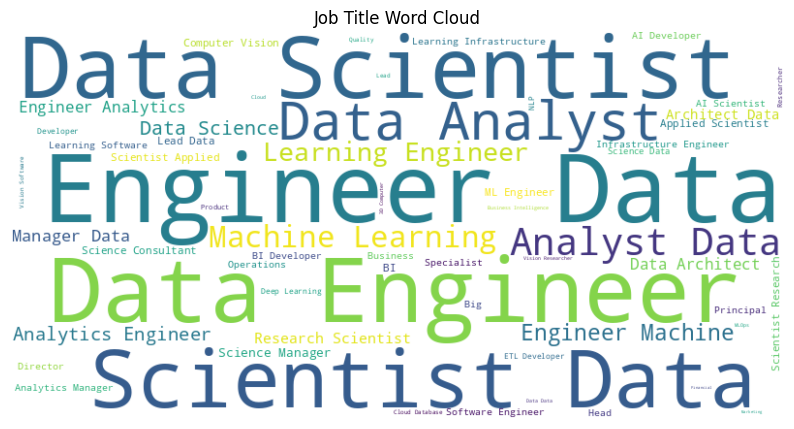

In [59]:
from wordcloud import WordCloud
text= " ".join(df["job_title"])
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Job Title Word Cloud")
plt.show()

**Insight:**  
The most frequently appearing job titles are "Data Scientist," "Data Engineer," "Machine Learning Engineer," "Analytics Engineer," and "Data Analyst." This reflects the dominance of generalist and engineering roles in the dataset.



### 4.2 Employment Type Word Cloud

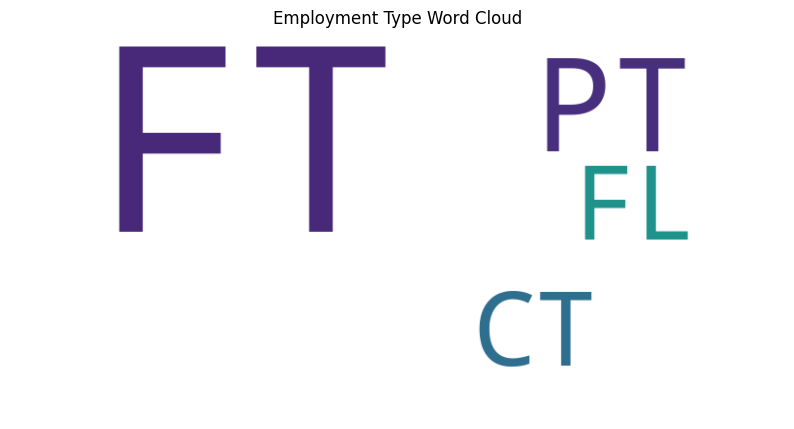

In [60]:
from wordcloud import WordCloud
text= " ".join(df["employment_type"])
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Employment Type Word Cloud")
plt.show()

**Insight:**  
"FT" (Full-Time) overwhelmingly dominates the word cloud, confirming that the dataset is primarily composed of full-time positions, with "CT" (Contract) and "PT" (Part-Time) being negligible.


## 5.Geography

In [61]:
import folium
import pandas as pd

residence_data = df.groupby("employee_residence")["salary_in_usd"].mean().reset_index()
location_data  = df.groupby("company_location")["salary_in_usd"].mean().reset_index()
residence_data.columns = ["country", "avg_salary"]
location_data.columns  = ["country", "avg_salary"]

alpha2_to_alpha3 = {
    'US': 'USA',
    'GB': 'GBR',
    'CA': 'CAN',
    'IN': 'IND',
    'ES': 'ESP',
    'DE': 'DEU',
    'FR': 'FRA',
    'IT': 'ITA',
    'NL': 'NLD',
    'PT': 'PRT',
    'CH': 'CHE',
    'SE': 'SWE',
    'NO': 'NOR',
    'DK': 'DNK',
    'FI': 'FIN',
    'IE': 'IRL',
    'BE': 'BEL',
    'AT': 'AUT',
    'PL': 'POL',
    'CZ': 'CZE',
    'HU': 'HUN',
    'RO': 'ROU',
    'BG': 'BGR',
    'GR': 'GRC',
    'TR': 'TUR',
    'IL': 'ISR',
    'ZA': 'ZAF',
    'NG': 'NGA',
    'KE': 'KEN',
    'GH': 'GHA',
    'EG': 'EGY',
    'MA': 'MAR',
    'TN': 'TUN',
    'DZ': 'DZA',
    'SA': 'SAU',
    'AE': 'ARE',
    'SG': 'SGP',
    'MY': 'MYS',
    'ID': 'IDN',
    'PH': 'PHL',
    'VN': 'VNM',
    'TH': 'THA',
    'JP': 'JPN',
    'CN': 'CHN',
    'HK': 'HKG',
    'TW': 'TWN',
    'KR': 'KOR',
    'AU': 'AUS',
    'NZ': 'NZL',
    'BR': 'BRA',
    'MX': 'MEX',
    'AR': 'ARG',
    'CL': 'CHL',
    'CO': 'COL',
    'PE': 'PER',
    'VE': 'VEN',
    'UY': 'URY',
    'PY': 'PRY',
    'BO': 'BOL',
    'EC': 'ECU',
    'GT': 'GTM',
    'CR': 'CRI',
    'PA': 'PAN',
    'DO': 'DOM',
    'CU': 'CUB',
    'PR': 'PRI',
    'JM': 'JAM',
    'TT': 'TTO',
    'BS': 'BHS',
    'BB': 'BRB',
    'SR': 'SUR',
    'GY': 'GUY',
    'PK': 'PAK',
    'BD': 'BGD',
    'LK': 'LKA',
    'NP': 'NPL',
    'MM': 'MMR',
    'KH': 'KHM',
    'LA': 'LAO',
    'MN': 'MNG',
    'UZ': 'UZB',
    'KZ': 'KAZ',
    'RU': 'RUS',
    'UA': 'UKR',
    'BY': 'BLR',
    'MD': 'MDA',
    'GE': 'GEO',
    'AM': 'ARM',
    'AZ': 'AZE',
    'IR': 'IRN',
    'IQ': 'IRQ',
    'SY': 'SYR',
    'LB': 'LBN',
    'JO': 'JOR',
    'YE': 'YEM',
    'KW': 'KWT',
    'BH': 'BHR',
    'QA': 'QAT',
    'OM': 'OMN',
    'AF': 'AFG',
    'TJ': 'TJK',
    'TM': 'TKM',
    'KG': 'KGZ',
    'EE': 'EST',
    'LV': 'LVA',
    'LT': 'LTU',
    'SI': 'SVN',
    'HR': 'HRV',
    'BA': 'BIH',
    'RS': 'SRB',
    'ME': 'MNE',
    'AL': 'ALB',
    'MK': 'MKD',
    'IS': 'ISL',
    'MT': 'MLT',
    'CY': 'CYP',
}

def to_alpha3(code):
    """Convert two-letter country code to three-letter, return None if unknown."""
    return alpha2_to_alpha3.get(code.upper())

residence_data["code"] = residence_data["country"].apply(to_alpha3)
location_data["code"]   = location_data["country"].apply(to_alpha3)

residence_data = residence_data.dropna(subset=["code"])
location_data  = location_data.dropna(subset=["code"])

geojson_url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"

map_res = folium.Map(location=[20, 0], zoom_start=2)
folium.Choropleth(
    geo_data=geojson_url,
    name="choropleth_residence",
    data=residence_data,
    columns=["code", "avg_salary"],
    key_on="feature.id",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Avg Salary (USD) by Employee Residence"
).add_to(map_res)
folium.LayerControl().add_to(map_res)
map_res.save("map_employee_residence.html")


map_loc = folium.Map(location=[20, 0], zoom_start=2)
folium.Choropleth(
    geo_data=geojson_url,
    name="choropleth_location",
    data=location_data,
    columns=["code", "avg_salary"],
    key_on="feature.id",
    fill_color="Blues",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Avg Salary (USD) by Company Location"
).add_to(map_loc)
folium.LayerControl().add_to(map_loc)



In [62]:
map_res

In [63]:
map_loc

##  Geographic Insights
- 🇺🇸 **North America** dominates — highest salaries ($150K+), largest job market
- 🇮🇱 **Israel is an outlier** — salaries rival or exceed the US (small but high-paying market)
- 🇪🇺 **Western Europe trails** — UK, Germany, Switzerland are 2nd tier ($100K–$140K)
-  **Asia, Latin America, Eastern Europe are low-wage zones** ($10K–$70K)
-  **Same-country work pays more** — domestic employees earn ~$154K vs ~$92K for international
-  **The map would reveal a clear global salary hierarchy** — North America > Europe > Rest of World
-  **Strategic takeaway**: companies exploit this gap via remote hiring — US/Israel firms hire into low-wage regions to cut costs
